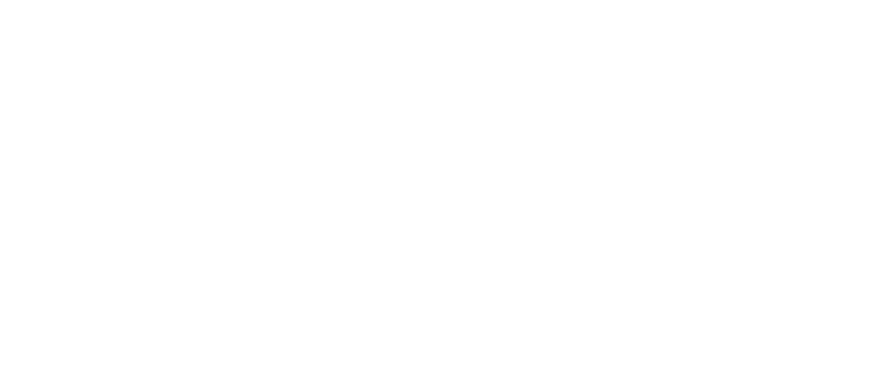

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
X, y = make_blobs(n_samples=400,
                  centers=4,
                  cluster_std=1.5,
                  random_state=42)

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5)
plt.title("Habitantes de Aldea Datos — Clusters no tan separados")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

In [ ]:
silhouette_scores = []
inertias = [] # SSE
k_values = range(2, 8)

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()

for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42)  # Define el numero de clusters
    labels = kmeans.fit_predict(X)                   # Aplica el modelo y obtiene las etiquetas
    centers = kmeans.cluster_centers_                # Obtiene las coordenadas de los centroides
    inertia = kmeans.inertia_                        # Inercia: suma de distancias intra-cluster
    score = silhouette_score(X, labels)              # Calcula el Silhouette Score

    silhouette_scores.append(score)
    inertias.append(inertia)


    axs[idx].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)
    axs[idx].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroides')
    axs[idx].set_title(f"k={k} | Silhouette={score:.2f} | Inercia={inertia:.0f}")
    axs[idx].set_xlabel("Caracteristica 1")
    axs[idx].set_ylabel("Caracteristica 2")
    axs[idx].legend()

plt.tight_layout()
plt.suptitle("Resultados de K-Means para distintos valores de k", fontsize=16, y=1.03)
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', color='blue')
plt.title("Silhouette Score vs Número de Clusters (k)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='s', color='orange')
plt.title("Inercia vs Número de Clusters (k)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia (Distancia total intra-cluster)")
plt.grid(True)
plt.show()

# **Preguntas**

1. **Si en la aldea hay una gran mayoria de personas en un grupo y muy pocos en otros, como podria afectar esto la formacion de los clusteres? Que tipo de sesgo se podria generar en la agrupacion?**

**Respuesta:**

Cuando existe un desbalance marcado en la distribucion de los datos, K-Means tiende a generar varios tipos de sesgo:

- **Sesgo de tamano:** El algoritmo minimiza la inercia total, por lo que los grupos grandes dominan el calculo de los centroides. El centroide del grupo mayoritario puede desplazarse hacia zonas de menor concentracion real.
- **Fragmentacion del grupo grande:** Para equilibrar las distancias, K-Means puede dividir el grupo mayoritario en dos o mas clusteres artificiales, aunque en realidad formen una sola comunidad natural.
- **Absorcion de grupos pequenos:** Los grupos minoritarios pueden quedar absorbidos por el centroide mas cercano del grupo grande, desapareciendo como comunidad independiente.

En la Aldea Datos, esto significaria que los sabios podrian dividir equivocadamente a los habitantes mas numerosos, mientras las pequenas comunidades quedarian invisibles o mal representadas.

2. **Supon que el nuevo habitante esta muy lejos del resto de la aldea. Que implicaciones tiene esto para el modelo K-Means? Como lo clasificaria el algoritmo y que tan confiable seria esa asignacion?**

**Respuesta:**

Un habitante muy alejado del resto representa un **valor atipico (outlier)**. Sus implicaciones son:

- **Distorsion de centroides:** K-Means es sensible a outliers porque el centroide se calcula como el promedio de sus miembros. Si el outlier queda asignado a un grupo, desplazara el centroide lejos del nucleo real de esa comunidad.
- **Asignacion forzada:** El algoritmo siempre asignara ese habitante al cluster cuyo centroide este mas cercano, aunque la distancia sea enorme. K-Means no tiene mecanismo para declarar un punto como ruido.
- **Confiabilidad baja:** La asignacion seria poco confiable. Un Silhouette Score muy bajo para ese punto indicaria que no pertenece naturalmente a ningun grupo. Se recomienda detectar outliers antes de aplicar K-Means, o usar algoritmos como DBSCAN que manejan el ruido explicitamente.

3. **Si un grupo de habitantes esta ubicado entre dos clusteres claramente formados, como afecta esto al resultado del algoritmo? Que papel juega el valor de K en este tipo de situaciones?**

**Respuesta:**

Cuando un grupo de puntos se ubica en la zona intermedia entre dos clusteres bien definidos, K-Means enfrenta ambiguedad en la asignacion:

- **Inestabilidad de fronteras:** Los puntos intermedios pueden cambiar de cluster entre iteraciones, haciendo que el algoritmo tarde mas en converger o que el resultado dependa de la inicializacion aleatoria.
- **Division arbitraria:** K-Means traza una frontera lineal entre los clusteres. Los puntos intermedios quedan asignados segun que lado de esa linea les corresponda, lo cual puede no reflejar la estructura real.
- **Papel del valor K:** Con K pequeno, los puntos intermedios se fusionan con uno de los dos grupos principales. Con K mas grande, podrian formar su propio cluster. La combinacion del metodo del codo (inercia) y el Silhouette Score ayuda a encontrar el K que mejor separa las comunidades sin crear divisiones artificiales.

4. **Cual fue la cantidad optima de clusteres segun los criterios mencionados en clase?**

**Respuesta:**

Utilizando los dos criterios aplicados en el notebook:

- **Metodo del Codo (Inercia):** La inercia disminuye a medida que aumenta K. El codo, punto donde la disminucion se vuelve menos pronunciada, se observa en **k=4**, lo que sugiere que agregar mas clusteres a partir de ahi aporta poco beneficio en compacidad.

- **Silhouette Score:** El puntaje mas alto tambien se alcanza en **k=4**, confirmando que esa cantidad produce los grupos mas cohesionados e internamente homogeneos.

Esto es consistente con el parametro `centers=4` usado al generar el dataset con `make_blobs`. Por lo tanto, la **cantidad optima de clusteres es K=4**, correspondiente a las 4 comunidades naturales de la Aldea Datos.